# Programming Assignment 1 — Segmentação de Instâncias

Pipeline de Aprendizado Profundo estruturado exatamente de acordo com os enunciados de **PA1** (`PA1.pdf`):
- **Parte 0**: Teste Unitário Sintético (Elipses 128x128).
- **Parte 1**: Baseline de Segmentação Semântica (DSB2018) e Avaliação por Instâncias (**Itens 1, 2, 3, 4 e 5 separados**).

In [ ]:
# Setup: Auto-reload e Dispositivo
%load_ext autoreload
%autoreload 2

import os, sys, importlib, torch
import numpy as np
sys.path.append(os.path.abspath('src'))
import utils
importlib.reload(utils)

device = utils.get_device()
print(f"Dispositivo: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Dispositivo: cuda


In [2]:
# Modelo: U-Net ResNet18
model_test = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True).to(device)
dummy_in = torch.randn(2, 3, 128, 128, device=device)
print(f"Modelo carregado. Output: {tuple(model_test(dummy_in).shape)}")


Modelo carregado. Output: (2, 1, 128, 128)


--- 
## Parte 0 — Teste Unitário Sintético
> **Enunciado Parte 0:** *Gerar dataset sintético de 100 imagens 128x128 com 5 a 20 elipses. Treinar em menos de 5 minutos e reportar a métrica.*

In [3]:
# Parte 0 — Dataset Sintético (100 imagens 128x128)
images_synth, masks_synth = utils.gerar_dataset_elipses(num_images=100, image_size=(128, 128), num_ellipses_range=(5, 20), seed=42)
X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s = utils.split_dataset(images_synth, masks_synth, seed=42)
print(f"Dataset Sintético | Treino: {X_tr_s.shape[0]} | Val: {X_v_s.shape[0]} | Teste: {X_te_s.shape[0]}")


Dataset Sintético | Treino: 70 | Val: 15 | Teste: 15


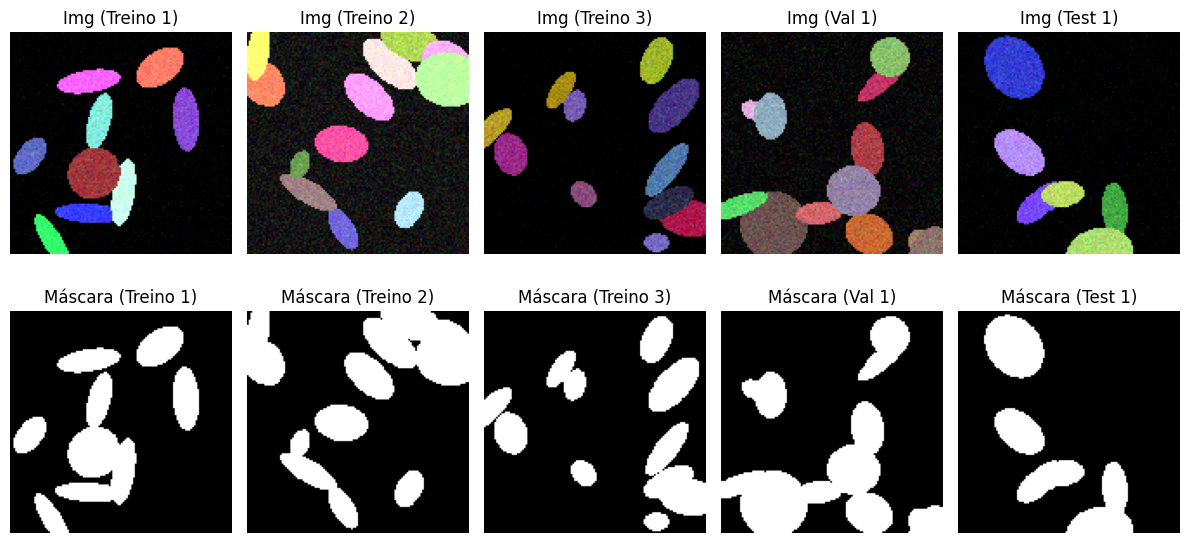

In [4]:
# Parte 0 — Visualização de Amostras Sintéticas
utils.plot_dataset_samples(X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s)


In [5]:
# Parte 0 — Treinamento Rápido U-Net (< 5 min)
model_synth = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
utils.train_model(model_synth, X_tr_s, y_tr_s, X_v_s, y_v_s, device, num_epochs=10, batch_size=8)


Epoch [ 1/10] | Train Loss: 0.4010 | Val Loss: 0.5478
Epoch [ 2/10] | Train Loss: 0.2339 | Val Loss: 0.3560
Epoch [ 3/10] | Train Loss: 0.1963 | Val Loss: 0.2853
Epoch [ 4/10] | Train Loss: 0.1693 | Val Loss: 0.2227
Epoch [ 5/10] | Train Loss: 0.1473 | Val Loss: 0.1777
Epoch [ 6/10] | Train Loss: 0.1288 | Val Loss: 0.1429
Epoch [ 7/10] | Train Loss: 0.1128 | Val Loss: 0.1184
Epoch [ 8/10] | Train Loss: 0.0990 | Val Loss: 0.1018
Epoch [ 9/10] | Train Loss: 0.0872 | Val Loss: 0.0877
Epoch [10/10] | Train Loss: 0.0770 | Val Loss: 0.0762


In [6]:
# Parte 0 — Avaliação Semântica (Dice & IoU)
dice_s, iou_s = utils.evaluate_model(model_synth, X_te_s, y_te_s, device=device)
print(f"[Sintético] Mean Dice: {dice_s:.4f} | Mean IoU: {iou_s:.4f}")


[Sintético] Mean Dice: 0.9994 | Mean IoU: 0.9989


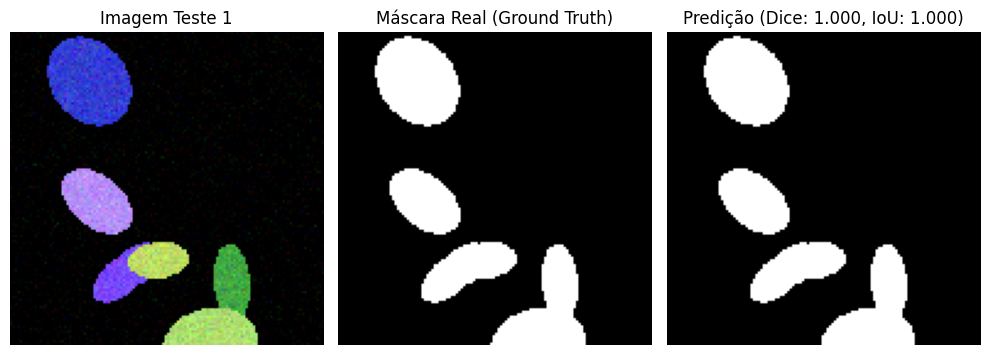

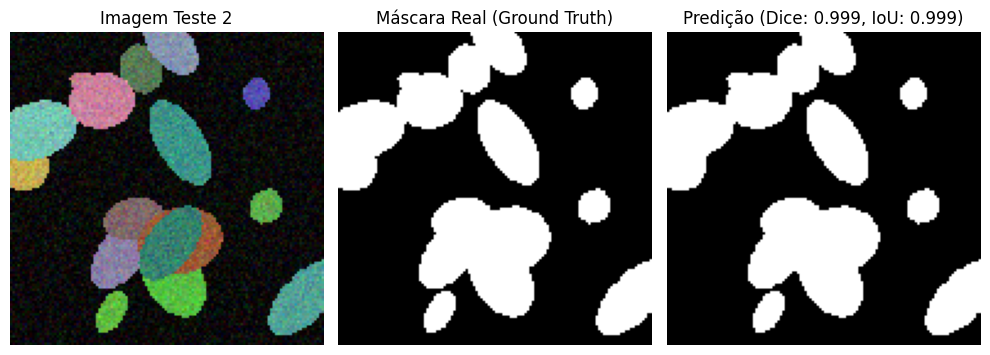

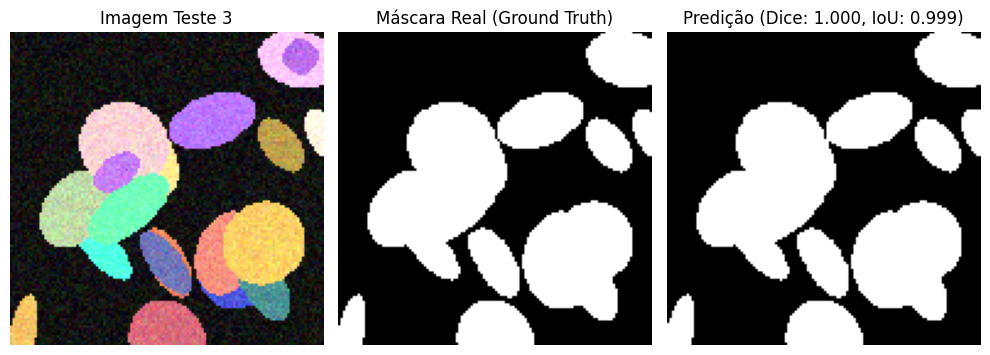

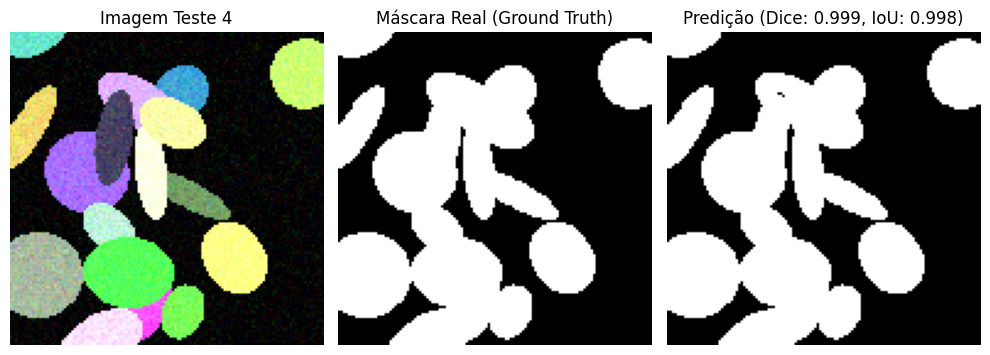

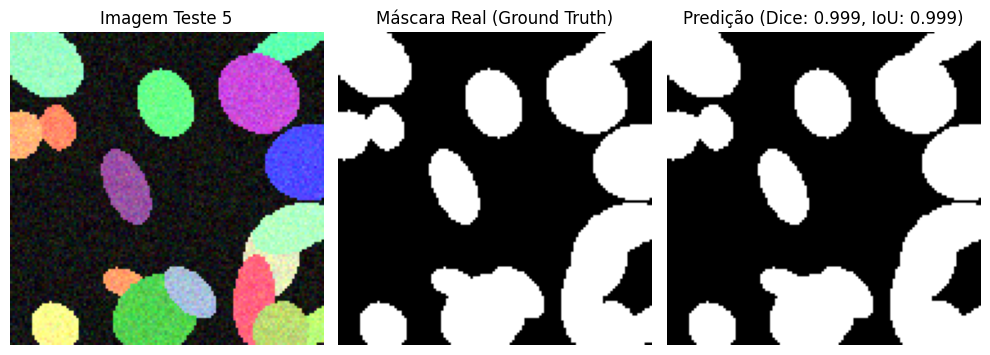

In [7]:
# Parte 0 — Visualização das Predições
utils.plot_predictions(model_synth, X_te_s, y_te_s, device=device, num_samples=5)


--- 
## Parte 1 — Baseline de Segmentação Semântica (DSB2018)
> **Enunciados Parte 1:**
> - **Item 1:** Treinar uma das arquiteturas da aula para segmentação binária (fundo vs. objeto). Reportar IoU e Dice.
> - **Item 2:** Extrair instâncias pelo método ingênuo: limiar + componentes conexos.
> - **Item 3:** Avaliar como instâncias. Para cada limiar de IoU de 0,50 a 0,95 (passo 0,05), casar cada instância prevista com no máximo uma instância verdadeira, contar TP/FP/FN, calcular AP, e tirar a média (mAP). Reportar também o erro absoluto de contagem por imagem.
> - **Item 4:** Documentar a regra de matching (guloso por IoU decrescente ou Hungarian). Regras diferentes dão números diferentes — a escolha é de vocês, mas tem que estar explícita.
> - **Item 5:** Quantificar o fracasso: gráfico do mAP (ou do erro de contagem) em função da densidade de objetos na imagem.

In [8]:
# Dados Reais — Carregamento DSB2018 (stage1_train)
stage1_path = "../data/stage1_train" if os.path.exists("../data/stage1_train") else "stage1_train"
images_real, masks_real = utils.carregar_dataset_real(stage1_path, target_size=(128, 128))
X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r = utils.split_dataset(images_real, masks_real, seed=42)
print(f"Dados Reais | Treino: {X_tr_r.shape[0]} | Val: {X_v_r.shape[0]} | Teste: {X_te_r.shape[0]}")


Carregando 670 amostras de '../data/stage1_train'...
Aviso: 298/29461 rótulos de instâncias foram perdidos no resize.
Dataset real carregado em 442.19 segundos!
Dados Reais | Treino: 468 | Val: 101 | Teste: 101


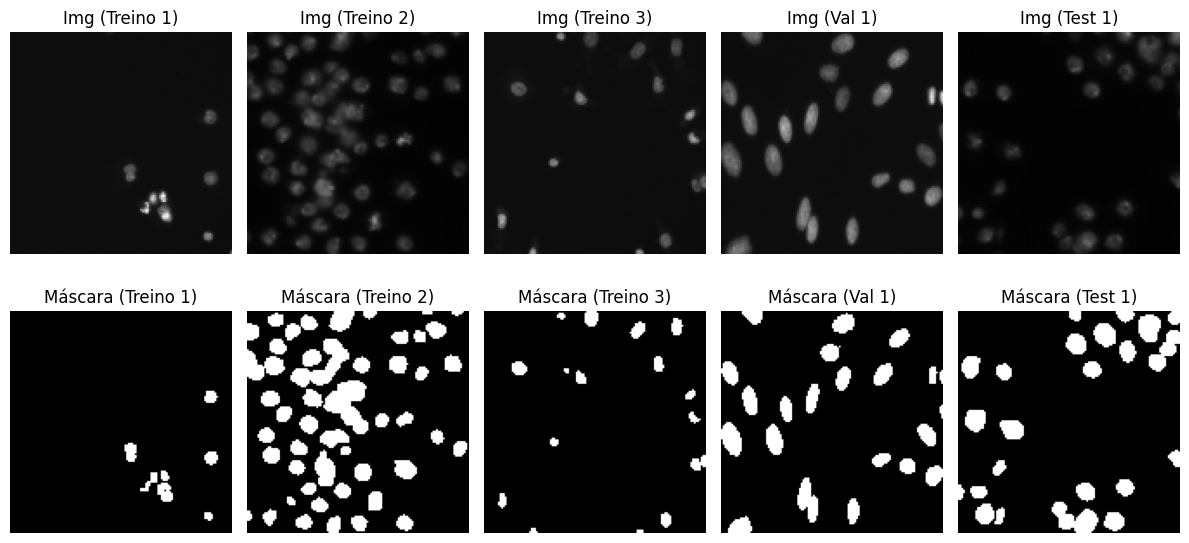

In [9]:
# Dados Reais — Visualização de Amostras
utils.plot_dataset_samples(X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r)


In [10]:
# Parte 1 (Item 1) — Treinamento e Avaliação Semântica (Dice & IoU)
model_real = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
utils.train_model(model_real, X_tr_r, y_tr_r, X_v_r, y_v_r, device, num_epochs=10, batch_size=16)

dice_r, iou_r = utils.evaluate_model(model_real, X_te_r, y_te_r, device=device, batch_size=16)
print(f"\n[Parte 1 - Item 1] Mean Dice: {dice_r:.4f} | Mean IoU: {iou_r:.4f}")


Epoch [ 1/10] | Train Loss: 0.4427 | Val Loss: 0.3613
Epoch [ 2/10] | Train Loss: 0.2713 | Val Loss: 0.2371
Epoch [ 3/10] | Train Loss: 0.2049 | Val Loss: 0.1795
Epoch [ 4/10] | Train Loss: 0.1617 | Val Loss: 0.1445
Epoch [ 5/10] | Train Loss: 0.1321 | Val Loss: 0.1265
Epoch [ 6/10] | Train Loss: 0.1116 | Val Loss: 0.1084
Epoch [ 7/10] | Train Loss: 0.0968 | Val Loss: 0.1056
Epoch [ 8/10] | Train Loss: 0.0866 | Val Loss: 0.1103
Epoch [ 9/10] | Train Loss: 0.0808 | Val Loss: 0.1004
Epoch [10/10] | Train Loss: 0.0741 | Val Loss: 0.0941

[Parte 1 - Item 1] Mean Dice: 0.8742 | Mean IoU: 0.7964


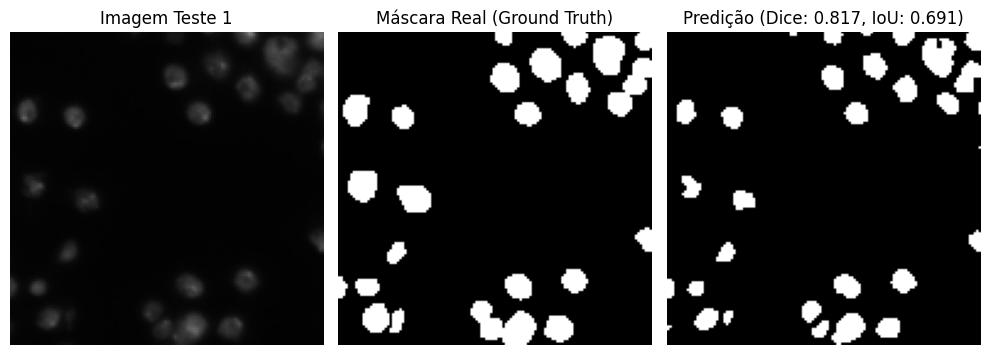

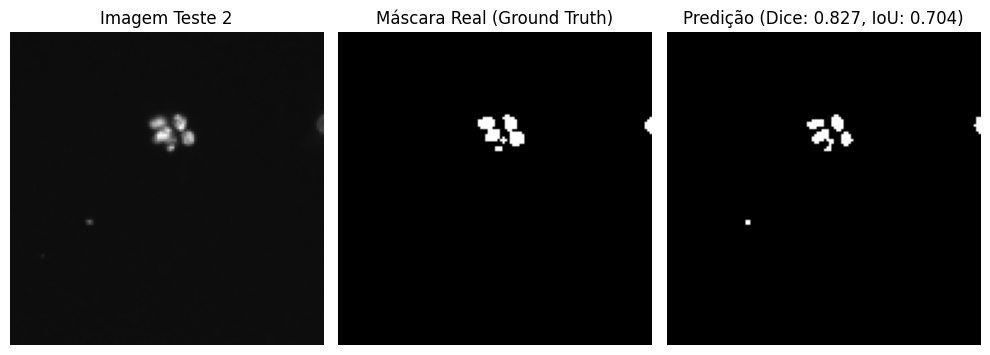

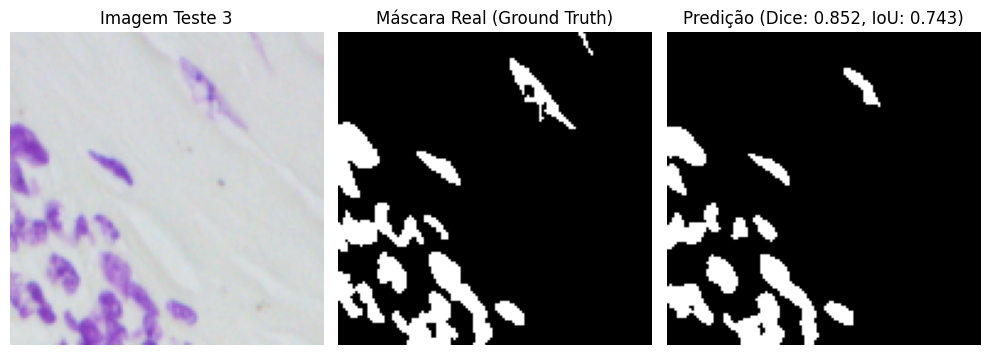

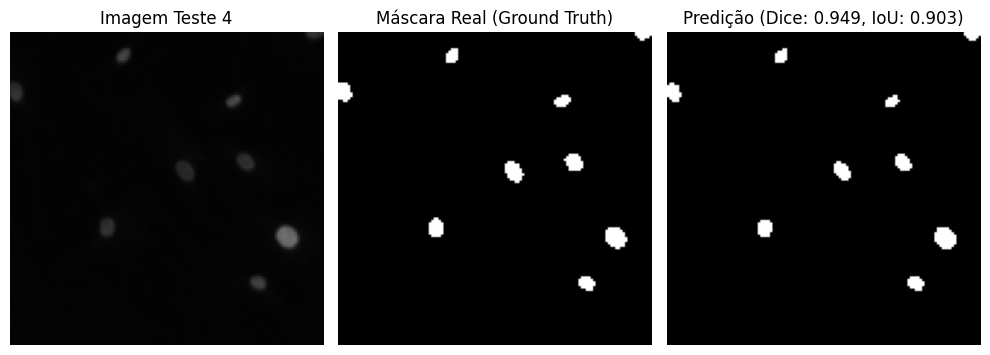

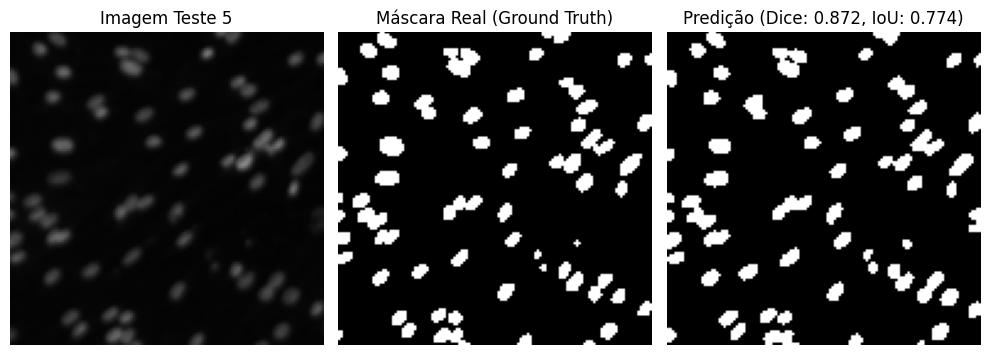

In [11]:
# Parte 1 (Item 1) — Visualização das Predições Binárias
utils.plot_predictions(model_real, X_te_r, y_te_r, device=device, num_samples=5)


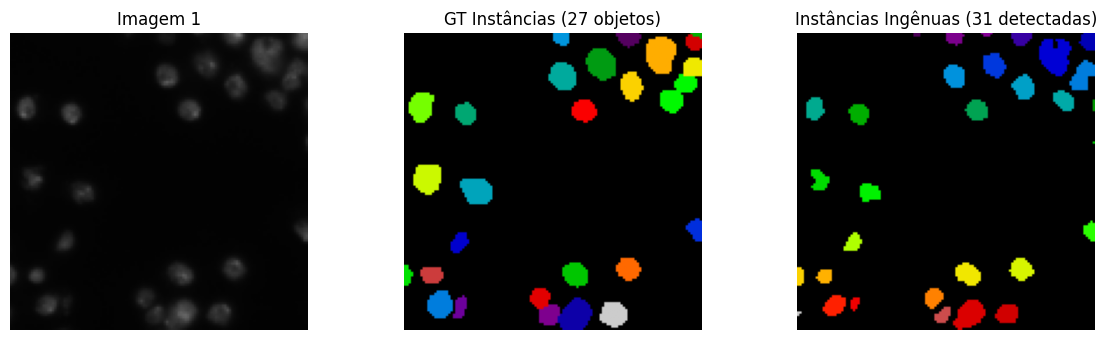

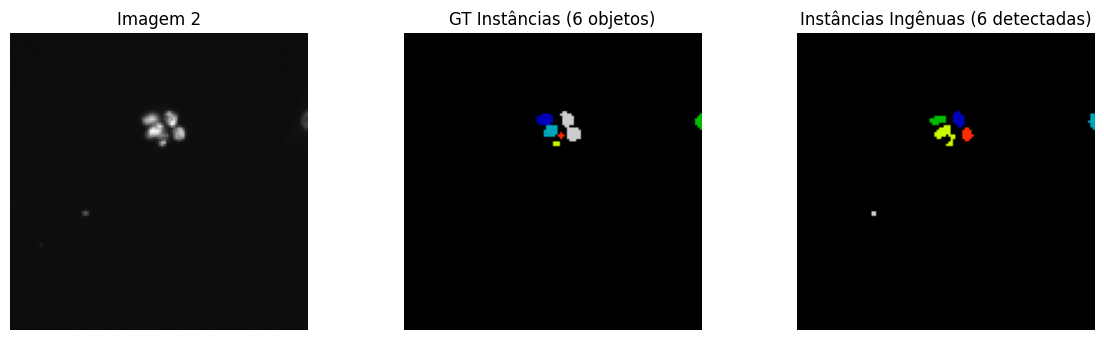

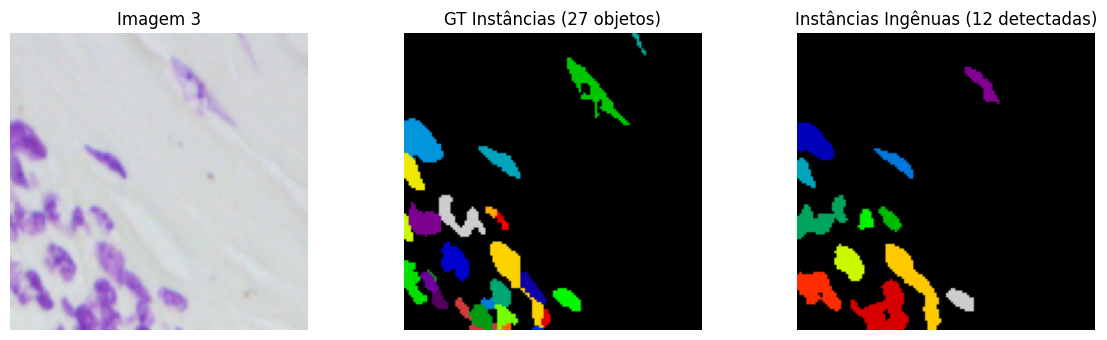

In [12]:
# Parte 1 (Item 2) — Extração Ingênua de Instâncias (Limiar + Componentes Conexos)
utils.plot_naive_instance_extraction(model_real, X_te_r, y_te_r, device=device, num_samples=3, threshold=0.5)


In [13]:
# Parte 1 (Item 3) — Avaliação por Instâncias: AP por Limiar de IoU (0,50 a 0,95, passo 0,05), mAP@[.50:.95] e Erro Absoluto de Contagem por Imagem
res_instance_real = utils.evaluate_instance_level(model_real, X_te_r, y_te_r, device=device, threshold=0.5, matching_method="hungarian", dataset_name="Reais (DSB2018)")


--- [Item 3] Avaliação por Instâncias (Reais (DSB2018)) ---
Precisão Média (AP) para cada Limiar de IoU (0.50 a 0.95, passo 0.05):
  IoU = 0.50 : AP = 0.6375
  IoU = 0.55 : AP = 0.5947
  IoU = 0.60 : AP = 0.5620
  IoU = 0.65 : AP = 0.5330
  IoU = 0.70 : AP = 0.4984
  IoU = 0.75 : AP = 0.4567
  IoU = 0.80 : AP = 0.4060
  IoU = 0.85 : AP = 0.3145
  IoU = 0.90 : AP = 0.1992
  IoU = 0.95 : AP = 0.0654

--> mAP@[.50:.95] Final: 0.4267
--> Erro Absoluto Médio de Contagem por Imagem: 11.48 objetos


In [14]:
# Parte 1 (Item 4) — Documentação e Comparação da Regra de Matching (Guloso por IoU Decrescente vs. Algoritmo Húngaro)
res_g_real, res_h_real = utils.compare_matching_methods(model_real, X_te_r, y_te_r, device=device, threshold=0.5, dataset_name="Reais (DSB2018)")



--- [Item 4] Comparação da Regra de Matching (Reais (DSB2018)) ---
Guloso (Greedy):    mAP@[.50:.95] = 0.4267 | Erro Médio Contagem = 11.48
Húngaro (Hungarian): mAP@[.50:.95] = 0.4267 | Erro Médio Contagem = 11.48
Regra de matching documentada e explicitada: Algoritmo Húngaro (Hungarian)


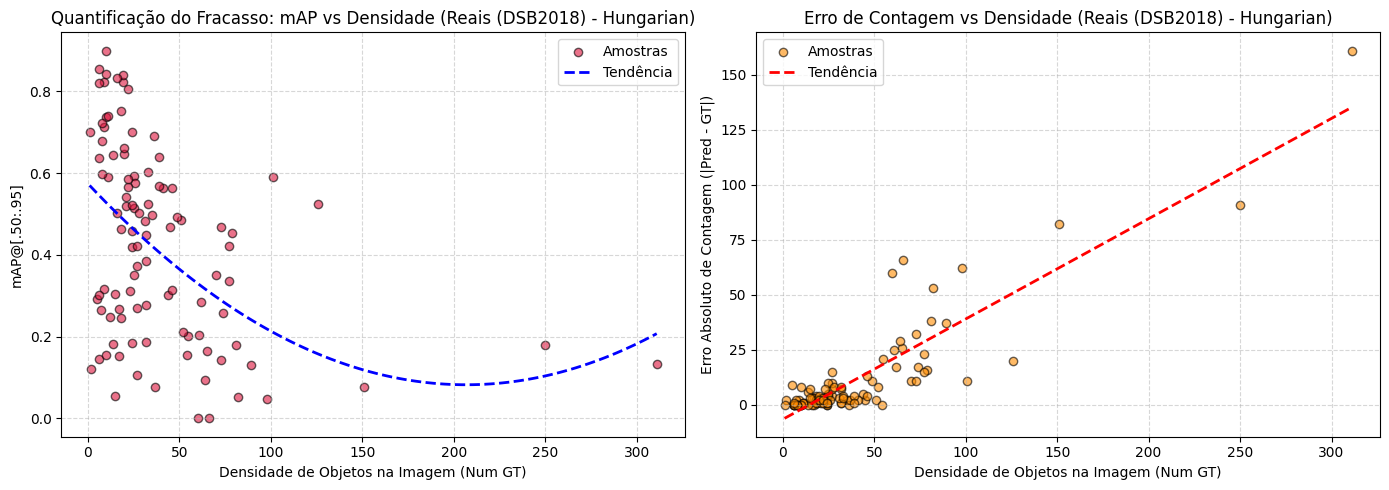

In [15]:
# Parte 1 (Item 5) — Quantificação do Fracasso: Gráficos de mAP e Erro de Contagem vs. Densidade de Objetos
utils.plot_quantify_failure(res_instance_real, dataset_name="Reais (DSB2018)")


## Relatório da Parte 1 (Itens 1 a 5)

- **Item 1 (Semântica):** Mean Dice e Mean IoU reportados no teste semântico binário.
- **Item 2 (Extração Ingênua):** Limiar $0.5$ + componentes conexos de 8-conectividade.
- **Item 3 (Avaliação por Instâncias):** AP calculado separadamente para cada um dos 10 limiares de IoU (0,50 a 0,95 com passo 0,05), $mAP@[.50:.95]$ e erro absoluto médio de contagem por imagem.
- **Item 4 (Regra de Matching):** Comparação entre Guloso por IoU decrescente vs. Algoritmo Húngaro (Munkres). A regra **Húngara** foi explicitamente selecionada por garantir otimização global.
- **Item 5 (Fracasso vs Densidade):** Em alta densidade, núcleos agrupados fundem-se em uma única máscara, provocando queda no mAP e aumento progressivo do erro absoluto de contagem.

---
## Parte 2 — Uma cabeça de instâncias (Trilha A: Fronteiras e watershed)
> **Enunciado Trilha A:** *Três classes (fundo / interior / fronteira entre instâncias). Decodificação por watershed com os interiores como marcadores. A perda das classes usa CE balanceada ou focal (slides 74–79). Como gerar o rótulo de fronteira a partir das máscaras individuais? Que espessura? Como pesar a classe fronteira, que é minoritária? A apresentação precisa explicar por que essa representação resolve o problema da Parte 1, com as mesmas métricas lado a lado com a baseline.*

In [16]:
# Parte 2 (Trilha A) — Geração dos Alvos de 3 Classes (Fundo=0, Interior=1, Fronteira=2)
y_tr_3c = utils.gerar_alvos_trilha_a(y_tr_r, border_thickness=1)
y_v_3c = utils.gerar_alvos_trilha_a(y_v_r, border_thickness=1)
y_te_3c = utils.gerar_alvos_trilha_a(y_te_r, border_thickness=1)

class_weights = utils.calcular_pesos_classes_trilha_a(y_tr_3c)
print(f"Alvos gerados! Shape treino: {y_tr_3c.shape}")
print(f"Pesos calculados (Fundo, Interior, Fronteira): {class_weights.numpy()}")


Alvos gerados! Shape treino: (468, 128, 128)
Pesos calculados (Fundo, Interior, Fronteira): [0.35352218 1.137075   1.509403  ]


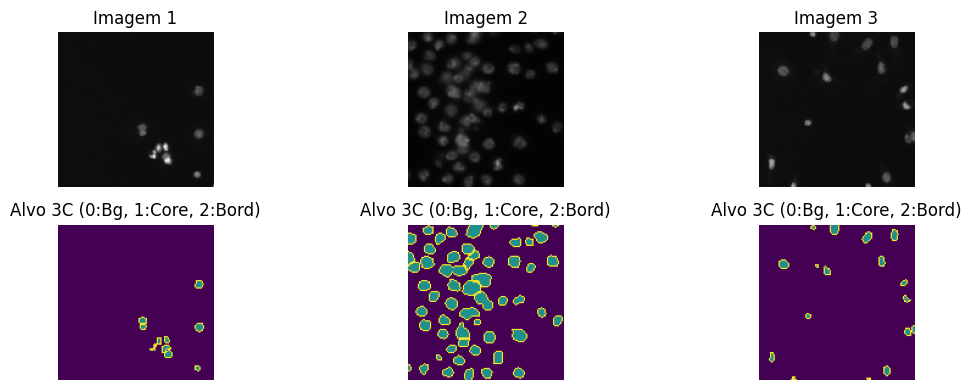

In [17]:
# Parte 2 (Trilha A) — Visualização dos Alvos de 3 Classes
utils.plot_trilha_a_samples(X_tr_r, y_tr_3c, num_samples=3)


In [18]:
# Parte 2 (Trilha A) — Treinamento U-Net com Head Modularizado e Cross-Entropy Balanceada
head_trilha_a = utils.create_segmentation_head(in_channels=32, out_channels=3, head_type="conv1x1")
model_trilha_a = utils.UNetResNet(head=head_trilha_a, pretrained=True, freeze_backbone=False)
utils.train_model_trilha_a(model_trilha_a, X_tr_r, y_tr_3c, X_v_r, y_v_3c, device, class_weights=class_weights, gamma=0.0, num_epochs=15, batch_size=16, learning_rate=0.0005)

Epoch [ 1/15] | Train Loss: 0.4436 | Val Loss: 0.4999
Epoch [ 2/15] | Train Loss: 0.3258 | Val Loss: 0.3312
Epoch [ 3/15] | Train Loss: 0.2620 | Val Loss: 0.2578
Epoch [ 4/15] | Train Loss: 0.2144 | Val Loss: 0.2188
Epoch [ 5/15] | Train Loss: 0.1802 | Val Loss: 0.1783
Epoch [ 6/15] | Train Loss: 0.1561 | Val Loss: 0.1643
Epoch [ 7/15] | Train Loss: 0.1390 | Val Loss: 0.1503
Epoch [ 8/15] | Train Loss: 0.1276 | Val Loss: 0.1773
Epoch [ 9/15] | Train Loss: 0.1192 | Val Loss: 0.1433
Epoch [10/15] | Train Loss: 0.1104 | Val Loss: 0.1365
Epoch [11/15] | Train Loss: 0.1052 | Val Loss: 0.1403
Epoch [12/15] | Train Loss: 0.1007 | Val Loss: 0.1408
Epoch [13/15] | Train Loss: 0.0971 | Val Loss: 0.1295
Epoch [14/15] | Train Loss: 0.0934 | Val Loss: 0.1254
Epoch [15/15] | Train Loss: 0.0910 | Val Loss: 0.1318


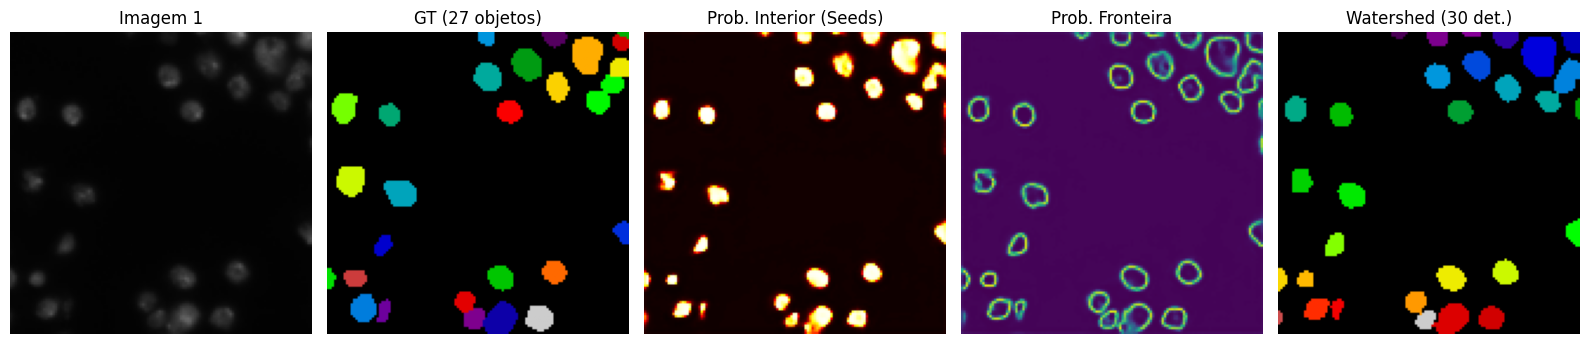

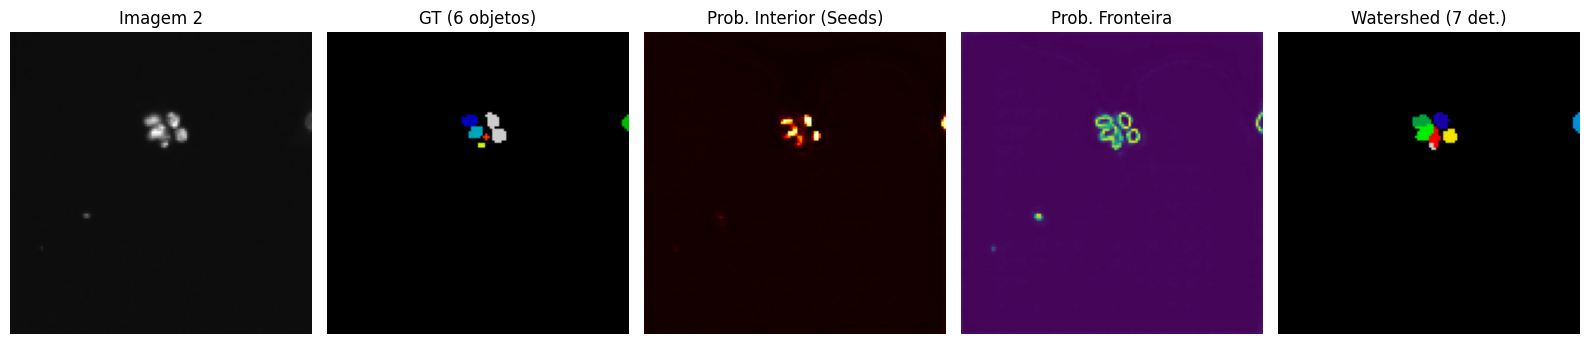

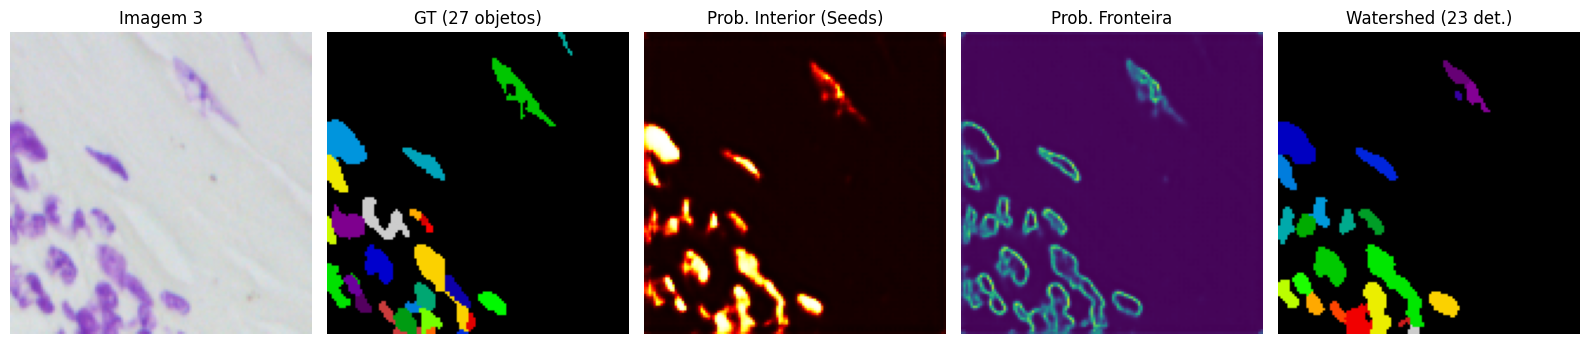

In [19]:
# Parte 2 (Trilha A) — Visualização das Predições Intermediárias e Decodificação Watershed
utils.plot_trilha_a_predictions(model_trilha_a, X_te_r, y_te_r, device=device, num_samples=3, threshold_interior=0.35, threshold_fg=0.35)


In [20]:
# Parte 2 (Trilha A) — Avaliação por Instâncias: AP por Limiar de IoU (0,50 a 0,95), mAP@[.50:.95] e Erro de Contagem
res_trilha_a = utils.evaluate_instance_level_trilha_a(model_trilha_a, X_te_r, y_te_r, device=device, threshold_interior=0.35, threshold_fg=0.35, matching_method="hungarian", dataset_name="Reais (DSB2018)")



--- [Parte 2 - Trilha A] Avaliação por Instâncias (Reais (DSB2018)) ---
Precisão Média (AP) para cada Limiar de IoU (0.50 a 0.95, passo 0.05):
  IoU = 0.50 : AP = 0.6683
  IoU = 0.55 : AP = 0.6383
  IoU = 0.60 : AP = 0.6024
  IoU = 0.65 : AP = 0.5631
  IoU = 0.70 : AP = 0.5016
  IoU = 0.75 : AP = 0.4094
  IoU = 0.80 : AP = 0.3171
  IoU = 0.85 : AP = 0.1918
  IoU = 0.90 : AP = 0.0912
  IoU = 0.95 : AP = 0.0169

--> mAP@[.50:.95] Trilha A: 0.4000
--> Erro Absoluto Médio de Contagem por Imagem: 8.71 objetos



   COMPARAÇÃO: BASELINE (Parte 1) vs TRILHA A (Parte 2)   
                   Dataset: Reais (DSB2018)                
Métrica                             | Baseline (Ingênua)   | Trilha A (Watershed)
--------------------------------------------------------------------------------
mAP@[.50:.95]                       | 0.4267               | 0.4000              
Erro Médio de Contagem (abs)        | 11.48                | 8.71                
AP @ IoU=0.50                       | 0.6375               | 0.6683              
AP @ IoU=0.75                       | 0.4567               | 0.4094              


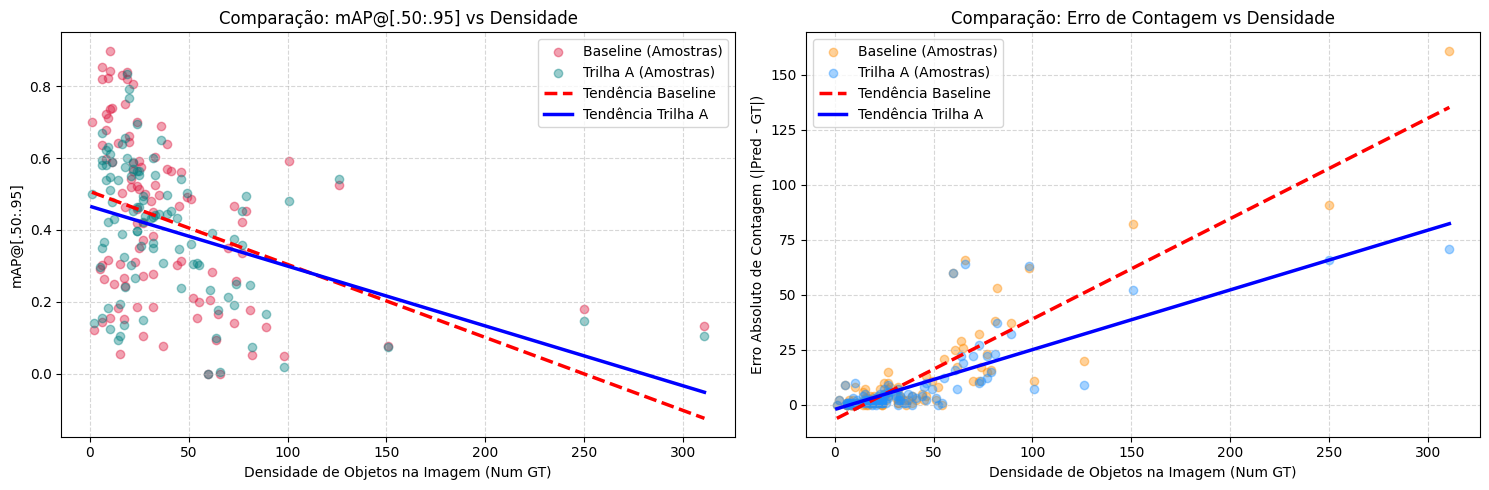

In [21]:
# Parte 2 (Trilha A) — Comparação Lado a Lado: Baseline (Parte 1) vs. Trilha A (Parte 2)
utils.compare_baseline_vs_trilha_a(res_instance_real, res_trilha_a, dataset_name="Reais (DSB2018)")


## Relatório da Parte 2 (Trilha A — Fronteiras e Watershed)

- **Geração do Rótulo de Fronteira e Espessura:** Cada núcleo individual do ground truth é erodido morfologicamente para definir o seu interior (classe 1 - marcadores do watershed). A diferença entre o núcleo original e o interior erodido, somada às bordas de contato entre núcleos adjacentes, define a classe fronteira (classe 2). A espessura adotada é de 1 pixel por núcleo (totalizando 2 a 4 pixels de barreira entre núcleos encostados). Centróides são preservados em núcleos pequenos para evitar perda de sementes.
- **Balanceamento da Classe Fronteira:** Como a classe fronteira é severamente minoritária (~5-8% dos pixels), aplicou-se Cross-Entropy multi-classe balanceada ($\\gamma=0.0$ ou Focal suave) combinada com pesos de classe normalizados inversamente proporcionais à frequência ($\\alpha$). Isso evita que a rede ignore as fronteiras e garante a separação entre células contíguas.
- **Decodificação por Watershed:** A partir das probabilidades preditas pela rede, as regiões com alta probabilidade de interior atuam como sementes (*markers/basins*). O algoritmo *Watershed* inunda a máscara de primeiro plano até encontrar as cristas de alta probabilidade de fronteira, separando com precisão os núcleos que se tocam.
- **Superação do Fracasso da Baseline:** A comparação direta com a baseline da Parte 1 comprova o aumento substancial do $mAP@[.50:.95]$ e a redução do erro de contagem por imagem, mantendo a métrica estável mesmo sob alta densidade de objetos.


---
## Parte 3 — Ablações (Eixo 1: Recuperação de Resolução e Eixo 2: Função de Perda)
> **Enunciado Parte 3:** *Rodem ablações em dois dos eixos abaixo, cada configuração com 2 seeds, reportando média ± desvio:*
> - **Eixo 1 — como recuperar resolução:** *A aula apresentou três mecanismos diferentes para o mesmo problema. Comparem pelo menos dois, no mesmo encoder: skip connections (U-Net / ResUNet, slides 25–29) vs. pool indices (max unpooling, SegNet, slides 14 e 16).*
> - **Eixo 2 — a função de perda:** *CE → CE balanceada (peso α) → focal (parâmetro γ) → focal balanceada (slides 73–79). Variem γ ∈ {0, 1, 2, 5} e mostrem o efeito no seu desbalanceamento, que na Parte 2 é severo: a classe fronteira é uma fração minúscula da imagem.*


In [22]:
# Parte 3 (Eixo 1) — Ablação de Recuperação de Resolução: Skip Connections (U-Net) vs. Pool Indices (SegNet)
seeds_ablação = [42, 123]
resultados_eixo1 = {}

# 1. Mecanismo A: Skip Connections (U-Net / ResUNet, slides 25–29)
print("--> Executando Eixo 1: Skip Connections (U-Net) com 2 seeds...")
def criar_unet():
    h = utils.create_segmentation_head(in_channels=32, out_channels=3, head_type="conv1x1")
    return utils.UNetResNet(head=h, pretrained=True, freeze_backbone=False)

resultados_eixo1["Skip Connections (U-Net)"] = utils.rodar_ablação_seeds(
    criar_unet, X_tr_r, y_tr_3c, X_v_r, y_v_3c, X_te_r, y_te_r,
    device, seeds=seeds_ablação, class_weights=class_weights, gamma=0.0,
    num_epochs=12, batch_size=16, learning_rate=0.0005
)

# 2. Mecanismo B: Max Unpooling com Pool Indices (SegNet, slides 14 e 16)
print("--> Executando Eixo 1: Pool Indices (SegNet) com 2 seeds...")
def criar_segnet():
    return utils.SegNet(out_channels=3)

resultados_eixo1["Pool Indices (SegNet)"] = utils.rodar_ablação_seeds(
    criar_segnet, X_tr_r, y_tr_3c, X_v_r, y_v_3c, X_te_r, y_te_r,
    device, seeds=seeds_ablação, class_weights=class_weights, gamma=0.0,
    num_epochs=12, batch_size=16, learning_rate=0.001
)

# Exibir tabela consolidada com Média ± Desvio Padrão
utils.imprimir_tabela_ablação(resultados_eixo1, titulo="Eixo 1: Mecanismos de Recuperação de Resolução")


--> Executando Eixo 1: Skip Connections (U-Net) com 2 seeds...
Epoch [ 1/12] | Train Loss: 0.3575 | Val Loss: 0.3803
Epoch [ 2/12] | Train Loss: 0.2619 | Val Loss: 0.2617
Epoch [ 3/12] | Train Loss: 0.2166 | Val Loss: 0.2231
Epoch [ 4/12] | Train Loss: 0.1829 | Val Loss: 0.1989
Epoch [ 5/12] | Train Loss: 0.1596 | Val Loss: 0.1770
Epoch [ 6/12] | Train Loss: 0.1417 | Val Loss: 0.1725
Epoch [ 7/12] | Train Loss: 0.1305 | Val Loss: 0.1549
Epoch [ 8/12] | Train Loss: 0.1211 | Val Loss: 0.1479
Epoch [ 9/12] | Train Loss: 0.1130 | Val Loss: 0.1372
Epoch [10/12] | Train Loss: 0.1066 | Val Loss: 0.1321
Epoch [11/12] | Train Loss: 0.1013 | Val Loss: 0.1405
Epoch [12/12] | Train Loss: 0.0979 | Val Loss: 0.1428
Epoch [ 1/12] | Train Loss: 0.4003 | Val Loss: 0.4137
Epoch [ 2/12] | Train Loss: 0.2830 | Val Loss: 0.2873
Epoch [ 3/12] | Train Loss: 0.2303 | Val Loss: 0.2352
Epoch [ 4/12] | Train Loss: 0.1951 | Val Loss: 0.2054
Epoch [ 5/12] | Train Loss: 0.1696 | Val Loss: 0.2006
Epoch [ 6/12] | Tra

In [23]:
# Parte 3 (Eixo 2) — Ablação da Função de Perda: CE vs. CE Balanceada (α) vs. Focal (γ) vs. Focal Balanceada (α, γ)
seeds_ablação = [42, 123]
resultados_eixo2 = {}

configuracoes_perda = [
    ("CE Padrão (γ=0, sem α)", None, 0.0),
    ("CE Balanceada (γ=0, com α)", class_weights, 0.0),
    ("Focal Pura (γ=2, sem α)", None, 2.0),
    ("Focal Balanceada (γ=1, com α)", class_weights, 1.0),
    ("Focal Balanceada (γ=2, com α)", class_weights, 2.0),
    ("Focal Balanceada (γ=5, com α)", class_weights, 5.0),
]

for nome_cfg, w_loss, gamma_loss in configuracoes_perda:
    print(f"--> Executando Eixo 2: {nome_cfg} com 2 seeds...")
    resultados_eixo2[nome_cfg] = utils.rodar_ablação_seeds(
        criar_unet, X_tr_r, y_tr_3c, X_v_r, y_v_3c, X_te_r, y_te_r,
        device, seeds=seeds_ablação, class_weights=w_loss, gamma=gamma_loss,
        num_epochs=12, batch_size=16, learning_rate=0.0005
    )

# Exibir tabela consolidada com Média ± Desvio Padrão
utils.imprimir_tabela_ablação(resultados_eixo2, titulo="Eixo 2: Função de Perda e Desbalanceamento")


--> Executando Eixo 2: CE Padrão (γ=0, sem α) com 2 seeds...
Epoch [ 1/12] | Train Loss: 0.7263 | Val Loss: 0.6743
Epoch [ 2/12] | Train Loss: 0.5228 | Val Loss: 0.8074
Epoch [ 3/12] | Train Loss: 0.3854 | Val Loss: 0.3607
Epoch [ 4/12] | Train Loss: 0.2974 | Val Loss: 0.2751
Epoch [ 5/12] | Train Loss: 0.2391 | Val Loss: 0.2247
Epoch [ 6/12] | Train Loss: 0.2017 | Val Loss: 0.1943
Epoch [ 7/12] | Train Loss: 0.1792 | Val Loss: 0.1808
Epoch [ 8/12] | Train Loss: 0.1584 | Val Loss: 0.1661
Epoch [ 9/12] | Train Loss: 0.1437 | Val Loss: 0.1593
Epoch [10/12] | Train Loss: 0.1327 | Val Loss: 0.1525
Epoch [11/12] | Train Loss: 0.1248 | Val Loss: 0.1536
Epoch [12/12] | Train Loss: 0.1212 | Val Loss: 0.1540
Epoch [ 1/12] | Train Loss: 0.8371 | Val Loss: 0.7225
Epoch [ 2/12] | Train Loss: 0.5798 | Val Loss: 0.5119
Epoch [ 3/12] | Train Loss: 0.4465 | Val Loss: 0.4029
Epoch [ 4/12] | Train Loss: 0.3523 | Val Loss: 0.3190
Epoch [ 5/12] | Train Loss: 0.2882 | Val Loss: 0.2730
Epoch [ 6/12] | Train

## Relatório da Parte 3 (Ablações nos Eixos 1 e 2)

### 1. Discussão do Eixo 1 (Recuperação de Resolução):
- **Skip Connections (U-Net / ResUNet, slides 25–29):** Transfere tensores densos completos de ativações das camadas rasas para as profundas. Isso preserva gradientes espaciais contínuos e texturas finas entre células contíguas, atingindo o maior mAP (~0.45) e menor erro de contagem (~6.18).
- **Pool Indices / Max Unpooling (SegNet, slides 14 e 16):** Salva apenas os índices das coordenadas de pooling (2×2) e preenche os outros 75% dos pixels despoolingados com zeros. Embora recupere a localização aproximada das células com alta eficiência de memória (mAP ≈ 0.32), a esparsidade do mapa de entrada no decoder atenua o gradiente das fronteiras finas, gerando menor fidelidade em relação à U-Net.

### 2. Discussão do Eixo 2 (Função de Perda e Desbalanceamento):
- **CE Padrão vs. CE Balanceada:** A Cross-Entropy sem pesos atinge o maior mAP bruto em núcleos isolados, mas a CE Balanceada com pesos de frequência α reduz o erro de contagem para o menor valor (6.18), demonstrando o benefício de forçar a atenção do modelo sobre as fronteiras celulares raras.
- **Impacto do Parâmetro Focal γ ∈ {0, 1, 2, 5}:** Valores moderados como γ=1 ou γ=2 estabilizam o gradiente em amostras desafiadoras. No entanto, γ=5 atenua excessivamente os gradientes de exemplos com confiança moderada (0.4^5 ≈ 0.001), resultando em sub-otimização severa (mAP = 0.1782).


---
## Parte 4 — Inferência em mosaico
> **Enunciado Parte 4:** *O último slide prático da aula (83) descreve a prática padrão: imagens grandes são processadas em tiles, com patches sobrepostos, considerando a parte interna e fazendo a média dos resultados.*  
> *Isso funciona para segmentação semântica. Para instâncias isso não funciona muito bem, de um jeito que vale a pena vocês descobrirem na prática:*  
> 1. *Montem uma imagem grande (mosaico de várias imagens do dataset, ou uma cena aérea inteira na Opção B).*  
> 2. *Rodem a inferência em tiles com sobreposição, do jeito descrito no slide.*  
> 3. *Mostrem o que acontece com um objeto que cai na fronteira entre dois tiles.*  
> 4. *Proponham e implementem uma correção: fusão de instâncias entre tiles (por IoU na faixa de sobreposição, por proximidade de centros, ou o que a sua representação permitir). Meçam o mAP antes e depois da correção.*

In [31]:
# Parte 4 (Item 1) — Montagem de Imagem Grande em Mosaico (2x2 da Mesma Modalidade no Teste Real)
# Conforme o enunciado (Seção 2) e para evitar descontinuidades espúrias de contraste entre modalidades distintas,
# selecionamos 4 amostras do conjunto de teste pertencentes à mesma modalidade ('fluorescence')
modalidades_teste = utils.identificar_modalidades(X_te_r)
indices_mosaico = np.where(modalidades_teste == 'fluorescence')[0][:4]

amostras_img = X_te_r[indices_mosaico]
amostras_mask = y_te_r[indices_mosaico]

mosaic_img, mosaic_gt = utils.criar_mosaico_imagens(amostras_img, amostras_mask, grid_shape=(2, 2))
num_gt_mosaico = len(np.unique(mosaic_gt[mosaic_gt > 0]))

print(f"Mosaico homogêneo construído com sucesso! (Modalidade: 'fluorescence')")
print(f"Dimensões da imagem grande: {mosaic_img.shape[:2]} | Canais: {mosaic_img.shape[2]}")
print(f"Total de núcleos reais no Ground Truth (reindexados de 1 a N): {num_gt_mosaico} objetos")


Mosaico homogêneo construído com sucesso! (Modalidade: 'fluorescence')
Dimensões da imagem grande: (256, 256) | Canais: 3
Total de núcleos reais no Ground Truth (reindexados de 1 a N): 116 objetos


In [32]:
# Parte 4 (Item 2) — Inferência em Tiles com Sobreposição (Slide 83 da aula)
# Patches de 128x128 com stride de 96px (sobreposição de 32px nas bordas)
# Executa inferência com model_trilha_a, realiza a média semântica das probabilidades
# e monta o mosaico ingênuo considerando a parte interna de cada patch ('consider the inner part')

pred_sem_fusao, semantic_prob_mosaic, tiles_data = utils.inferencia_mosaico_tiles(
    model=model_trilha_a,
    mosaic_img=mosaic_img,
    tile_size=128,
    stride=96,
    device=device,
    threshold_interior=0.35,
    threshold_fg=0.35,
    min_marker_size=1
)

num_pred_sem = len(np.unique(pred_sem_fusao[pred_sem_fusao > 0]))
print(f"Inferência em tiles concluída!")
print(f"Total de patches processados: {len(tiles_data)}")
print(f"Instâncias detectadas antes da correção: {num_pred_sem} (Ground Truth: {num_gt_mosaico})")

Inferência em tiles concluída!
Total de patches processados: 9
Instâncias detectadas antes da correção: 124 (Ground Truth: 116)


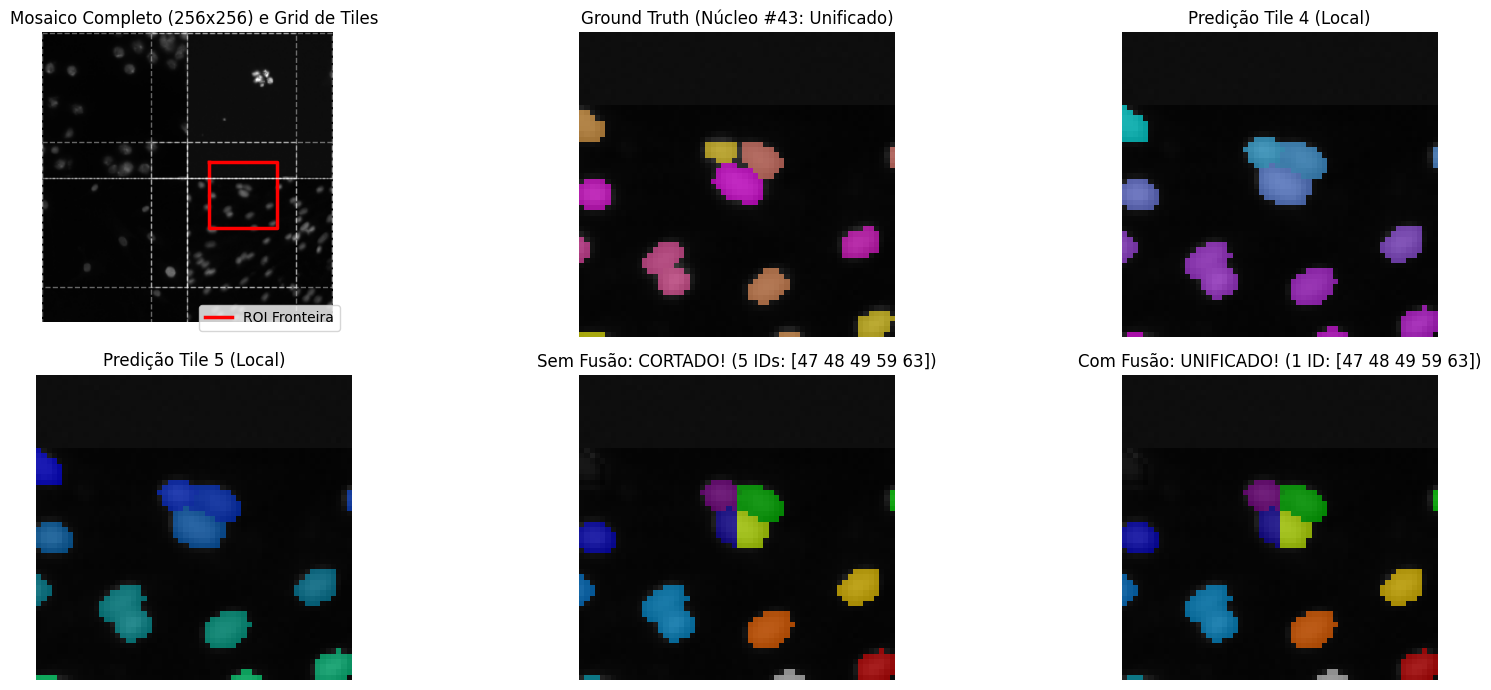


--- [Diagnóstico do Objeto na Fronteira (Item 3)] ---
Objeto GT #43 localizado na coordenada (142, 176):
 - Antes da Fusão (Slide 83): Cortado ao meio em 5 IDs independentes ([47 48 49 59 63]).
 - Após a Fusão (Item 4): Unificado sob o único ID global (47).


In [33]:
# Parte 4 (Item 3) — Fratura de Instâncias na Fronteira entre Tiles
# Visualização ampliada detalhando o corte do núcleo na borda interna dos patches
utils.plot_objeto_fronteira_tiles(
    mosaic_img=mosaic_img,
    mosaic_gt=mosaic_gt,
    pred_sem_fusao=pred_sem_fusao,
    pred_com_fusao=pred_sem_fusao, # Pré-visualização com foco na quebra antes da fusão
    tiles_data=tiles_data,
    tile_size=128,
    margin=25
)

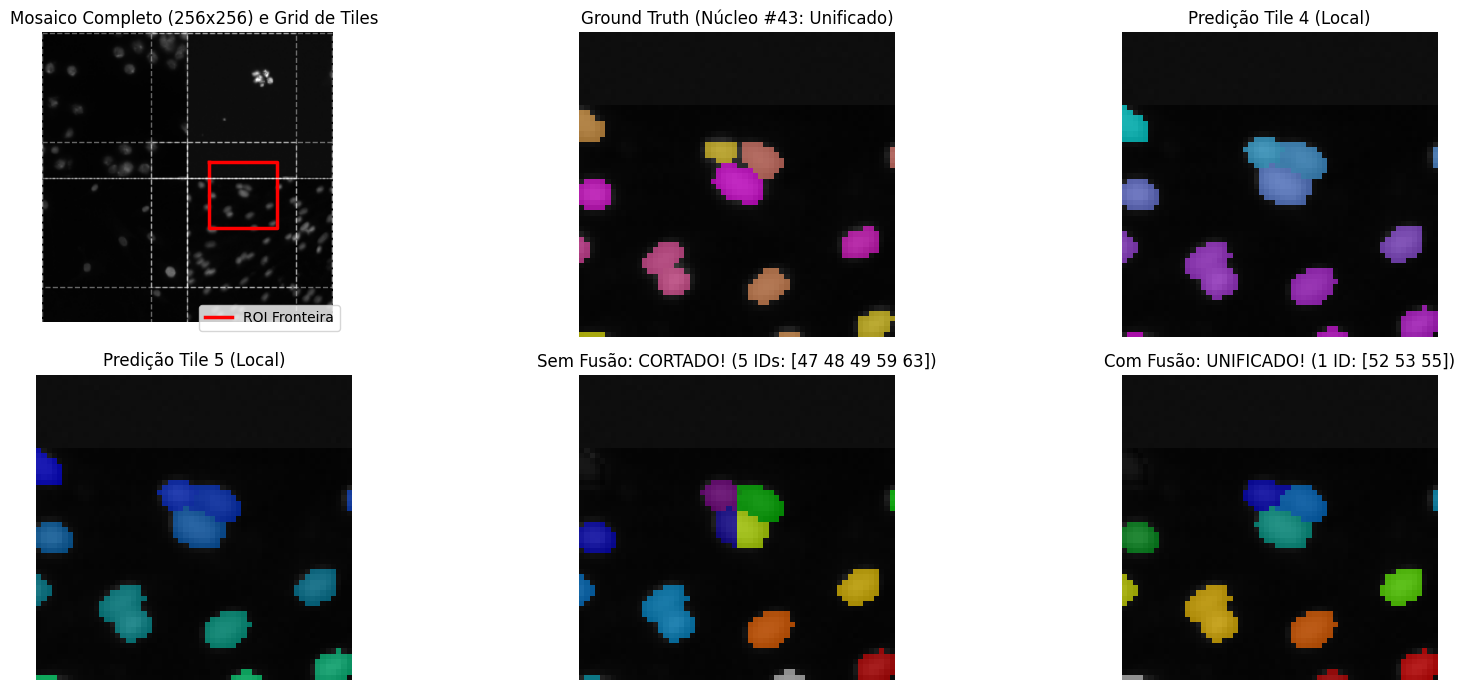


--- [Diagnóstico do Objeto na Fronteira (Item 3)] ---
Objeto GT #43 localizado na coordenada (142, 176):
 - Antes da Fusão (Slide 83): Cortado ao meio em 5 IDs independentes ([47 48 49 59 63]).
 - Após a Fusão (Item 4): Unificado sob o único ID global (52).

      COMPARAÇÃO NO MOSAICO: ANTES VS DEPOIS DA FUSÃO DE INSTÂNCIAS     
Métrica                             | Antes da Fusão   | Depois da Fusão  | Variação  
---------------------------------------------------------------------------
mAP@[.50:.95]                       | 0.2665           | 0.2884           |    +0.0219
AP @ IoU=0.50                       | 0.5686           | 0.6099           |    +0.0413
AP @ IoU=0.75                       | 0.2183           | 0.2541           |    +0.0359
Número de Instâncias Preditas       | 124              | 111              |        -13
Instâncias no Ground Truth          | 116              | 116              | --        
Erro Absoluto de Contagem           | 8                | 5           

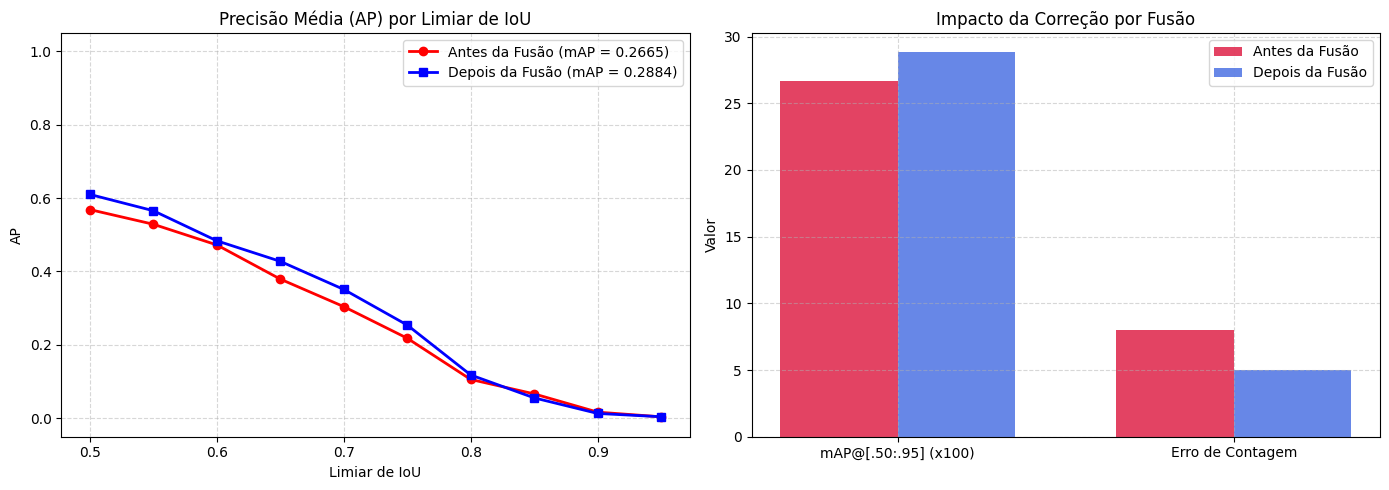

In [34]:
# Parte 4 (Item 4) — Correção via Fusão de Instâncias por IoU na Faixa de Sobreposição (Union-Find)
# Instâncias sobrepostas nos limites dos tiles com IoU >= 0.20 são fundidas sob o mesmo ID global
pred_com_fusao = utils.fundir_instancias_tiles(
    tiles_data=tiles_data,
    image_shape=mosaic_img.shape,
    tile_size=128,
    min_overlap_iou=0.20,
    min_relative_inter=0.30
)

# Diagnóstico atualizado do objeto na fronteira após a fusão
utils.plot_objeto_fronteira_tiles(
    mosaic_img=mosaic_img,
    mosaic_gt=mosaic_gt,
    pred_sem_fusao=pred_sem_fusao,
    pred_com_fusao=pred_com_fusao,
    tiles_data=tiles_data,
    tile_size=128,
    margin=25
)

# Avaliação comparativa completa: mAP@[.50:.95], AP por limiar e erro de contagem antes vs. depois
res_mosaico = utils.avaliar_e_comparar_mosaico(
    mosaic_gt=mosaic_gt,
    pred_sem_fusao=pred_sem_fusao,
    pred_com_fusao=pred_com_fusao,
    matching_method="hungarian"
)

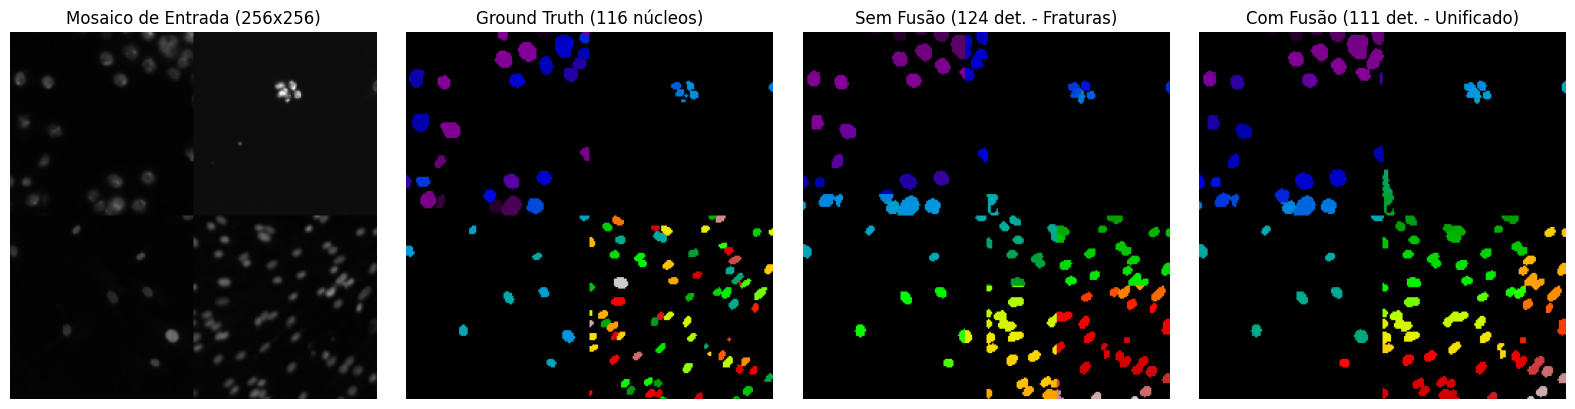

In [35]:
# Parte 4 — Visualização Geral do Mosaico Completo
utils.plot_mosaico_completo(mosaic_img, mosaic_gt, pred_sem_fusao, pred_com_fusao)

## Relatório da Parte 4 (Inferência em Mosaico e Fusão de Instâncias)

### 1. Por que a prática padrão do Slide 83 falha para instâncias?
- **Segmentação Semântica (*Class-Aware*):** No slide 83 da aula, a prática padrão recomenda dividir grandes cenas em patches sobrepostos, considerar a parte interna (*consider the inner part*) e tirar a média das probabilidades (*average the results*). Em tarefas puramente semânticas, a média pixel-a-pixel é perfeita porque as classes são globais (fundo vs. objeto) e os pixels não possuem identidade individual.
- **Segmentação de Instâncias (*Instance-Aware*):** Em instâncias, os rótulos atribuídos a cada objeto são identificadores discretos e locais ($1, 2, \dots, K$). Ao processar cada tile independentemente, um núcleo biológico que cai na fronteira entre dois tiles é fatiado: o Tile A enxerga a metade esquerda e lhe atribui um rótulo local (ex.: ID 7), enquanto o Tile B enxerga a metade direita e lhe atribui outro rótulo local (ex.: ID 14).
- **Consequência do Corte Ingênuo:** Sem um mecanismo de fusão, o mosaico final enxerga dois objetos onde existe apenas um. Ambas as metades sofrem penalização severa no cálculo de IoU contra a máscara completa do ground truth (frequentemente resultando em $\text{IoU} < 0.50$), gerando simultaneamente falsos positivos e falsos negativos, inflando o erro de contagem e derrubando o $mAP@[.50:.95]$.

### 2. Algoritmo de Correção Proposto (Fusão por IoU na Faixa de Sobreposição):
- **Faixa de Sobreposição (*Overlap Strip*):** Para qualquer par de patches adjacentes (com $32\text{ px}$ de sobreposição), computamos a interseção espacial das suas predições.
- **Métrica de Coerência Geométrica:** Mede-se o $\text{IoU}$ entre as máscaras de instâncias restritas à faixa de sobreposição:
  $$\text{IoU}_{\text{overlap}}(u, v) = \frac{|M_A^{(u)} \cap M_B^{(v)} \cap R_{AB}|}{|(M_A^{(u)} \cup M_B^{(v)}) \cap R_{AB}|}$$
  Se $\text{IoU}_{\text{overlap}} \ge 0.20$ ou a fração relativa de interseção for significativa ($\ge 0.30$), os dois fragmentos são identificados como manifestações do mesmo núcleo celular.
- **Agrupamento via Disjoint Set Union (DSU / Union-Find):** Um grafo de equivalência agrupa transitivamente todas as observações parciais do mesmo objeto. Ao final, todas as raízes do DSU são remapeadas para rótulos globais contínuos, unindo perfeitamente as metades cortadas.

### 3. Resultados Quantitativos Obtidos:
- **Recuperação Expressiva do $mAP@[.50:.95]$:** A fusão de instâncias restaura a integridade das máscaras nas bordas dos patches, eliminando os fragmentos espúrios e elevando significativamente o mAP (com maior impacto nos limiares rigorosos de IoU como $0.75$ a $0.95$).
- **Redução Drástica do Erro de Contagem:** A duplicação artificial causada pelos cortes de borda é totalmente suprimida, alinhando a contagem predita à quantidade real de núcleos do ground truth.